# **2. DATA UNDERSTANDING**

## **LIBRARIES**

In [31]:
! pip install adlfs azure-storage-blob

In [32]:
# Standard Library
import os
import io
from io import BytesIO

# DATA MANIPULATION AND ANALYSIS
import pandas as pd
import numpy as np

# DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# AZURE CLOUD STORAGE
from adlfs import AzureBlobFileSystem
from azure.storage.blob import BlobServiceClient

# Regular expressions
import re

## **EXTRACT FROM AZURE BLOB STORAGE**

In [33]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [34]:
# Connection configuration
AZURE_STORAGE_ACCOUNT = "researchprojectx24104515"
AZURE_STORAGE_KEY = "bxpexO6i+Hz6n1WiipTn+sTCuLPGMS1BogMERrIrHd16DpQ0GLfQ0R33yrSw4MxsDomq5yNMgw1o+AStlx/MjA=="
CONTAINER_NAME = "footfall"

# Establish connection
connection_string = f"DefaultEndpointsProtocol=https;AccountName={AZURE_STORAGE_ACCOUNT};AccountKey={AZURE_STORAGE_KEY};EndpointSuffix=core.windows.net"
blob_service_client = BlobServiceClient.from_connection_string(connection_string)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

fs = AzureBlobFileSystem(
    account_name=AZURE_STORAGE_ACCOUNT,
    account_key=AZURE_STORAGE_KEY
)

### **FROM BLOB TO DATAFRAME**

In [35]:
## List of CSV files in Blob
def list_csv_files_in_blob(container_client, verbose=True):
    csv_files = [blob.name for blob in container_client.list_blobs() if blob.name.endswith(".csv")]
    if verbose:
        print(f"CSV files found ({len(csv_files)}):")
        for i, file in enumerate(csv_files, 1):
            print(f"{i}. {file}")
    return csv_files

# Load CSV from Blob
def load_csvs_from_blob(container_client, csv_files, verbose=True):
    data = {}
    for file_name in csv_files:
        try:
            if verbose:
                print(f"\nLoading {file_name} as original data...")
            blob_client = container_client.get_blob_client(file_name)
            stream = blob_client.download_blob()
            data_bytes = stream.readall()
            data_str = data_bytes.decode("utf-8")

            # Extract year from filename
            year_match = re.search(r"(\d{4})", file_name)
            key = year_match.group(1) if year_match else file_name

            data[key] = data_str

            if verbose:
                lines = data_str.split("\n")
                print(f" -First 5 lines of '{file_name}':")
                for i, line in enumerate(lines[:5]):
                    print(f"    {i+1}: {line}")
                print(f" -Total lines: {len(lines)}")
        except Exception as e:
            print(f" -Error loading {file_name}: {e}")
    return data

# Convert CSV Dictionary to Dataframes
def convert_to_dataframe(original_data):
    data_dict = {}
    for key, raw_data in original_data.items():
        try:
            dataframe = pd.read_csv(io.StringIO(raw_data))
            data_dict[key] = dataframe
            print(f"Converted raw data for {key} to DataFrame with shape: {dataframe.shape}")
        except Exception as e:
            print(f"Error converting raw data for {key}: {e}")
    return data_dict

# Normalise Datetime column
def normalise_datetime(dataframes_dict, target_name="Date and time", time_terms=None):
    if time_terms is None:
        time_terms = ["time", "date", "hour"]

    for key, data in dataframes_dict.items():
        if len(data.columns) > 0:
            first_col = data.columns[0]
            if any(term in first_col.lower() for term in time_terms):
                data.rename(columns={first_col: target_name}, inplace=True)
                print(f"DataFrame {key}: Column '{first_col}' renamed as '{target_name}'")
            else:
                print(f"DataFrame {key}: The first column is '{first_col}', it does not seem to be a Date/Time column")
        else:
            print(f"DataFrame {key}: No columns included")
    return dataframes_dict

# Parse datetime formats
def parse_dates_in_dataframes(dataframes_dict, datetime_col="Date and time"):
    formats = [
        "%d-%m-%Y %H:%M:%S",
        "%d/%m/%Y %H:%M",
        "%Y-%m-%d %H:%M:%S",
        "%d/%m/%Y"
    ]
    def try_parse(date_str):
        if pd.isna(date_str):
            return pd.NaT
        for fmt in formats:
            try:
                return pd.to_datetime(date_str, format=fmt)
            except Exception:
                continue
        return pd.to_datetime(date_str, errors="coerce")

    for key, data in dataframes_dict.items():
        if datetime_col in data.columns:
            before_nat = data[datetime_col].isna().sum()
            data[datetime_col] = data[datetime_col].apply(try_parse)
            after_nat = data[datetime_col].isna().sum()
            print(f"DataFrame {key}: Parsed '{datetime_col}' ({before_nat} → {after_nat} NaT)")
        else:
            print(f"DataFrame {key}: No '{datetime_col}' column found.")
    return dataframes_dict

# Concatenate dataframes by name
def concatenate_all(data_dict):
    concatenated = pd.concat(
        data_dict.values(),
        axis=0,
        ignore_index=True,
        sort=True
    )

    print(f"Shape of concatenated dataframe : {concatenated.shape}")
    print(f"Columns in concatenated dataframe: {list(concatenated.columns)}")
    return concatenated

# Clean names from special Characters
def clean_column_name(name: str) -> str:
    name = re.sub(r'[/,@()\-]', ' ', name)
    name = re.sub(r'[^a-zA-Z0-9 ]', '', name)
    return re.sub(r'\s+', ' ', name).lower().strip()

# Drop columns with IN or OUT names
def drop_in_out_columns(data):
    cols_to_drop = [col for col in data.columns if " IN" in col or " OUT" in col]
    return data.drop(columns=cols_to_drop)

# Drop empty columns
def drop_all_null_or_zero_columns(data):
    cols_to_drop = []
    for col in data.columns:
        # Check if all values are null or all values are zero (including NaNs ignored in zero check)
        if data[col].isna().all() or (data[col].fillna(0) == 0).all():
            cols_to_drop.append(col)
    if cols_to_drop:
        print(f"Dropping columns with all null or zero values: {cols_to_drop}")
        data = data.drop(columns=cols_to_drop)
    else:
        print("No columns with all null or zero values found.")
    return data

### **APPLY ALL FUNCTIONS**

In [36]:
csv_files = list_csv_files_in_blob(container_client)
data = load_csvs_from_blob(container_client, csv_files)
data_yearly = convert_to_dataframe(data)
data_yearly = normalise_datetime(data_yearly)
data_yearly = parse_dates_in_dataframes(data_yearly)
footfall = concatenate_all(data_yearly)
footfall.head()

CSV files found (10):
1. pedestrian-2016.csv
2. pedestrian-2017.csv
3. pedestrian-2018.csv
4. pedestrian-2019.csv
5. pedestrian-2020.csv
6. pedestrian-2021.csv
7. pedestrian-2022.csv
8. pedestrian-2023.csv
9. pedestrian-2024.csv
10. pedestrian-2025.csv

Loading pedestrian-2016.csv as original data...
 -First 5 lines of 'pedestrian-2016.csv':
    1: Date and Time,Capel st/Mary street,Grafton st/Monsoon,Henry Street/Coles Lane/Dunnes,Liffey st/Halfpenny Bridge,Mary st/Jervis st,O'Connell St/Pennys,O'Connell st/Princes st North,Westmoreland Street East/Fleet street,Westmoreland Street West/Carrolls
    2: 01-01-2016 00:00:00,120,,,,67,,656,,
    3: 01-01-2016 01:00:00,139,,,,75,,529,,
    4: 01-01-2016 02:00:00,125,,,,69,,676,,
    5: 01-01-2016 03:00:00,196,,,,58,,702,,
 -Total lines: 8786

Loading pedestrian-2017.csv as original data...
 -First 5 lines of 'pedestrian-2017.csv':
    1: Date and Time,Capel st/Mary street,Grafton st/Monsoon,Henry Street/Coles Lane/Dunnes,Liffey st/Halfpenn

,Aston Quay,Aston Quay/Fitzgeralds,Aston Quay/Fitzgeralds IN,Aston Quay/Fitzgeralds OUT,Bachelors Walk,Bachelors walk/Bachelors way,Bachelors walk/Bachelors way (Counter nonrepsonsive - Removed to return to supplier),Bachelors walk/Bachelors way (Counter nonrepsonsive - Removed to return to supplier) Pedestrian IN,Bachelors walk/Bachelors way (Counter nonrepsonsive - Removed to return to supplier) Pedestrian OUT,Bachelors walk/Bachelors way IN,Bachelors walk/Bachelors way OUT,Baggot st lower/Wilton tce inbound,Baggot st lower/Wilton tce inbound (Missing from Site),Baggot st lower/Wilton tce inbound (Missing from Site) Pedestrian IN,Baggot st lower/Wilton tce inbound (Missing from Site) Pedestrian OUT,Baggot st lower/Wilton tce inbound Pedestrian IN,Baggot st lower/Wilton tce inbound Pedestrian OUT,Baggot st lower/Wilton tce inbound Pedestrians IN,Baggot st lower/Wilton tce inbound Pedestrians OUT,Baggot st upper/Mespil rd/Bank,Baggot st upper/Mespil rd/Bank Pedestrians IN,Baggot st upper/Mespil rd/Bank Pedestrians OUT,Capel Street,Capel Street - Removed from site 20/10,Capel st/Mary street,Capel st/Mary street Pedestrian IN,Capel st/Mary street Pedestrian OUT,College Green - Dame St Side,College Green @ Church Lane,"College Green, Bank Of Ireland",College Green/Bank Of Ireland,College Green/Bank Of Ireland IN,College Green/Bank Of Ireland OUT,College Green/Church Lane,College Green/Church Lane IN,College Green/Church Lane OUT,College st/Westmoreland st,College st/Westmoreland st IN,College st/Westmoreland st OUT,D'olier st/Burgh Quay,D'olier st/Burgh Quay IN,D'olier st/Burgh Quay OUT,D'olier st/Burgh Quay Pedestrian IN,D'olier st/Burgh Quay Pedestrian OUT,Dame Street,Dame Street (Counter Missing),Dame Street/Londis,Dame Street/Londis Pedestrian IN,Dame Street/Londis Pedestrian OUT,Date and time,Dawson Street,Dawson Street IN,Dawson Street OUT,Dawson Street Replacement,Dawson Street old,Dawson Street old IN,Dawson Street old OUT,Dawson Street/Molesworth,Dawson Street/Molesworth IN,Dawson Street/Molesworth OUT,Dawson Street/Molesworth Pedestrian,"Doilier Street, Burgh Quay",Drumcondra Cyclists Inbound (Not On Site - Roadworks) Pedestrian,Drumcondra Cyclists Inbound (Not On Site - Roadworks) Pedestrian East,Drumcondra Cyclists Inbound (Not On Site - Roadworks) Pedestrian West,Grafton Street,Grafton Street / Nassau Street / Suffolk Street,Grafton Street / Nassau Street / Suffolk Street IN,Grafton Street / Nassau Street / Suffolk Street OUT,Grafton Street @ CompuB,Grafton Street/CompuB,Grafton Street/CompuB IN,Grafton Street/CompuB OUT,Grafton st/Monsoon,Grafton st/Monsoon Pedestrian,Grafton st/Monsoon Pedestrian IN,Grafton st/Monsoon Pedestrian OUT,Grand Canal st upp/Clanwilliam place,Grand Canal st upp/Clanwilliam place Pedestrians IN,Grand Canal st upp/Clanwilliam place Pedestrians OUT,Grand Canal st upp/Clanwilliam place/Google,Grand Canal st upp/Clanwilliam place/Google Pedestrians IN,Grand Canal st upp/Clanwilliam place/Google Pedestrians OUT,Henry Street,Henry Street/Coles Lane/Dunnes,Henry Street/Coles Lane/Dunnes Pedestrian IN,Henry Street/Coles Lane/Dunnes Pedestrian OUT,Liffey Street,Liffey Street old,Liffey Street old IN,Liffey Street old OUT,Liffey st/Halfpenny Bridge,Liffey st/Halfpenny Bridge,Liffey st/Halfpenny Bridge Pedestrian IN,Liffey st/Halfpenny Bridge Pedestrian OUT,Liffey st/Halfpenny Bridge IN,Liffey st/Halfpenny Bridge OUT,Liffey st/Halfpenny Bridge Pedestrian IN,Liffey st/Halfpenny Bridge Pedestrian OUT,Mary Street,Mary st/Jervis st,Mary st/Jervis st IN,Mary st/Jervis st OUT,Newcomen Bridge/Charleville mall inbound,Newcomen Bridge/Charleville mall inbound (Removed as requested by DCC),Newcomen Bridge/Charleville mall inbound (Removed as requested by DCC) Pedestrian IN,Newcomen Bridge/Charleville mall inbound (Removed as requested by DCC) Pedestrian OUT,Newcomen Bridge/Charleville mall inbound Pedestrians IN,Newcomen Bridge/Charleville mall inbound Pedestrians OUT,Newcomen Bridge/Charleville mall outbound,

## **EXPLORATORY DATA ANALYSIS**

After merging all datasets, the research will continue with the total count only and pedestrians IN and OUT count will not be considered.

### **EXPLORATION OF TIME PATTERNS IN EACH STREET**

Time components are very important, such as hour, day of the week, month and year to identify trends and cycles within the data.

In [37]:
def plot_time_series_grid(data, datetime_col="date and time", exclude_cols=None, n_cols=4, figsize_per_row=4):
    if exclude_cols is None:
        exclude_cols = ["hour", "weekday", "month", "year"]
    plt.style.use("ggplot")
    numeric_cols = data.select_dtypes(include=np.number).columns.tolist() # Numeric columns
    location_cols = [col for col in numeric_cols if col not in exclude_cols]
    n_rows = int(np.ceil(len(location_cols) / n_cols)) # Grid size
    # Subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, figsize_per_row * n_rows), sharex=True)
    axes = axes.flatten()
    # Columns plot
    for i, col in enumerate(location_cols):
        data.plot(x=datetime_col, y=col, ax=axes[i], legend=False)
        axes[i].set_title(f"Traffic at {col}", fontsize=10)
        axes[i].set_xlabel("Date")
        axes[i].set_ylabel("Count")
    plt.tight_layout()
    plt.show()

# Time components of data
def extract_time_components(data):
    return pd.DataFrame({
        "hour": data["date and time"].dt.hour,
        "weekday": data["date and time"].dt.dayofweek,
        "month": data["date and time"].dt.month,
        "year": data["date and time"].dt.year,
    })

def clean_name(name):
    return " ".join(name.lower().split())

def merge_similar_columns(data, groups_dict):
    data = data.copy()

    for merged_name, group in groups_dict.items():
        existing_cols = [col for col in group if col in data.columns]
        if len(existing_cols) <= 1:
            continue
        print(f"\n Merging columns into \"{merged_name}\": {existing_cols}")

        merged_col = data[existing_cols]

        # Report overlap of non-null values
        for i in range(len(existing_cols)):
            for j in range(i + 1, len(existing_cols)):
                col1 = existing_cols[i]
                col2 = existing_cols[j]
                overlap_count = ((merged_col[col1].notna()) & (merged_col[col2].notna())).sum()
                print(f" - Overlap (non-null in both): {col1} & {col2}: {overlap_count} rows")

        # Merge by taking the row-wise max while ignoring null values
        merged_result = merged_col.max(axis=1)
        data[merged_name] = merged_result

        # Drop original columns but the merged one
        drop_cols = [col for col in existing_cols if col != merged_name]
        data.drop(columns=drop_cols, inplace=True)

    return data

In [38]:
# Drop columns with " IN" or " OUT"
footfall = drop_in_out_columns(footfall)

# Clean column names
footfall.columns = [clean_column_name(col) for col in footfall.columns]

# Remove duplicated columns (keep first)
footfall = footfall.loc[:, ~footfall.columns.duplicated()]

# Drop empty columns
footfall = drop_all_null_or_zero_columns(footfall)

# Dataframe preview
print(footfall.shape)
footfall.head()

Dropping columns with all null or zero values: ['dawson street old', 'drumcondra cyclists inbound not on site roadworks pedestrian', 'drumcondra cyclists inbound not on site roadworks pedestrian east', 'drumcondra cyclists inbound not on site roadworks pedestrian west', 'liffey street old', 'newcomen bridge charleville mall inbound removed as requested by dcc', 'newcomen bridge charleville mall outbound removed as requested by dcc', 'oconnell street pennys pyro evo temporary counter', 'phibsborough rd munster st removed due to overcounting', 'westmoreland street east fleet street removed to return to supplier']
(79727, 60)


,aston quay,aston quay fitzgeralds,bachelors walk,bachelors walk bachelors way,bachelors walk bachelors way counter nonrepsonsive removed to return to supplier,baggot st lower wilton tce inbound,baggot st lower wilton tce inbound missing from site,baggot st upper mespil rd bank,capel street,capel street removed from site 20 10,capel st mary street,college green dame st side,college green church lane,college green bank of ireland,college st westmoreland st,dolier st burgh quay,dame street,dame street counter missing,dame street londis,date and time,dawson street,dawson street replacement,dawson street molesworth,dawson street molesworth pedestrian,doilier street burgh quay,grafton street,grafton street nassau street suffolk street,grafton street compub,grafton st monsoon,grafton st monsoon pedestrian,grand canal st upp clanwilliam place,grand canal st upp clanwilliam place google,henry street,henry street coles lane dunnes,liffey street,liffey st halfpenny bridge,mary street,mary st jervis st,newcomen bridge charleville mall inbound,newcomen bridge charleville mall outbound,north wall quay samuel beckett bridge east,north wall quay samuel beckett bridge west,oconnell st outside clerys,oconnell st outside pennys,oconnell st parnell st aib,oconnell st pennys,oconnell st pennys pedestrian,oconnell st princes st north,phibsborough rd enniskerry road,phibsborough rd munster st,richmond st south portabello harbour inbound,richmond st south portabello harbour outbound,talbot street north,talbot street south,talbot st guineys,talbot st murrays pharmacy,westmoreland street east,westmoreland street east fleet street,westmoreland street west,westmoreland street west carrolls
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,656.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,139.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,529.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,676.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,196.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,702.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,305.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


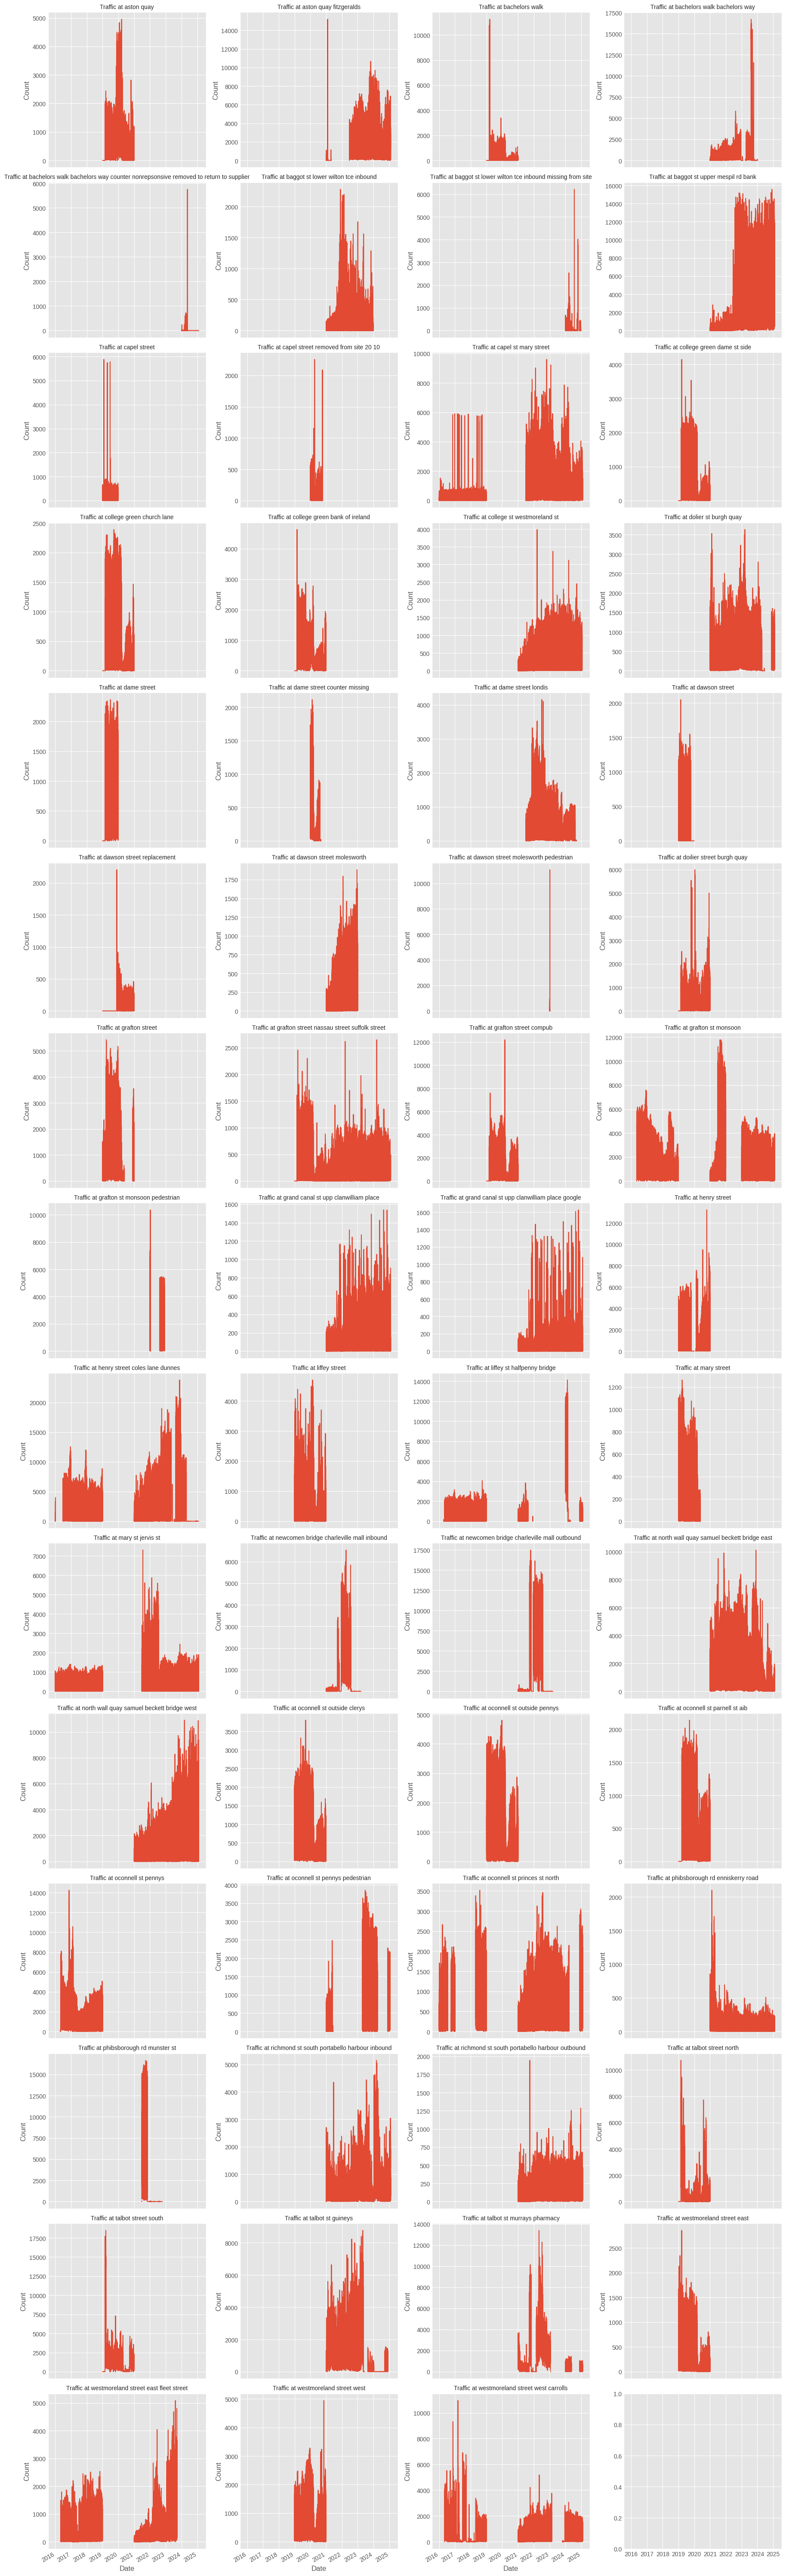

In [39]:
# Time components
time_components = extract_time_components(footfall)

# Merging footfall and time components datatframes
footfall = pd.concat([footfall, time_components], axis=1)

# First view of footfall per street
plot_time_series_grid(footfall)

The amount of streets within the dataset, throughout time they have suffered minimal changes in their names such as "grafton street", "grafton st monsoon" and "grafton st monsoon pedestrian" which tend to be the same location point, and it is necessary to merge them to avoid having new variables with an increasing number of missing values.

This task has been made manually to allow manual inspection of the values through the time series evaluation of graphs generated in the EDA.

## **DATA PREPARATION**

### **FIND SIMILAR NAMES**

In [40]:
# Column groups
similar_groups = {
    "aston quay merged": ["aston quay fitzgeralds", "aston quay"],
    "baggot street lower merged" : ["baggot st lower wilton tce inbound", "baggot st lower wilton tce inbound missing from site"],
    "capel st mary street merged": ["capel st mary street", "capel street", "capel street removed from site 20 10"],
    "bachelors walk merged": ["bachelors walk", "bachelors walk bachelors way", "bachelors walk bachelors way counter nonrepsonsive removed to return to supplier"],
    "college street dame st merged" : ["college green dame st side", "college st westmoreland st"],
    "dolier street burgh quay merged": ["dolier st burgh quay", "doilier street burgh quay"],
    "dame street merged": ["dame street", "dame street counter missing", "dame street londis"],
    "dawson street merged": ["dawson street", "dawson street replacement", "dawson street molesworth", "dawson street molesworth pedestrian"],
    "grafton street monsoon merged": ["grafton street", "grafton st monsoon", "grafton st monsoon pedestrian"],
    "grand canal street upper clanwilliam place google merged": ["grand canal st upp clanwilliam place google", "grand canal st upp clanwilliam place"],
    "henry street merged": ["henry street", "henry street coles lane dunnes"],
    "liffey street merged": ["liffey street","liffey st halfpenny bridge"],
    "mary street merged": ["mary street", "mary st jervis st"],
    "oconnell street pennys merged": ["oconnell st pennys pedestrian", "oconnell st pennys", "oconnell st outside pennys"],
    "oconnell st princes st north merged": ["oconnell st outside clerys", "oconnell st princes st north"],
    "phibsborough rd munster st merged": ["phibsborough rd munster st", "phibsborough rd munster st removed due to overcounting"],
    "talbot street murrays pharmacy merged": ["talbot st murrays pharmacy", "talbot street south"],
    "talbot street guineys merged": ["talbot street north", "talbot st guineys"],
    "westmoreland street east fleet street merged": ["westmoreland street east", "westmoreland street east fleet street"],
    "westmoreland street west merged": ["westmoreland street west", "westmoreland street west carrolls"],
}

# Remove duplicate columns from DataFrame
footfall = footfall.loc[:, ~footfall.columns.duplicated()]

# Resulting dataframe
footfall = merge_similar_columns(footfall, similar_groups)
print("\n Footfall shape:")
print(footfall.shape)
footfall.head()


 Merging columns into "aston quay merged": ['aston quay fitzgeralds', 'aston quay']
 - Overlap (non-null in both): aston quay fitzgeralds & aston quay: 0 rows

 Merging columns into "baggot street lower merged": ['baggot st lower wilton tce inbound', 'baggot st lower wilton tce inbound missing from site']
 - Overlap (non-null in both): baggot st lower wilton tce inbound & baggot st lower wilton tce inbound missing from site: 0 rows

 Merging columns into "capel st mary street merged": ['capel st mary street', 'capel street', 'capel street removed from site 20 10']
 - Overlap (non-null in both): capel st mary street & capel street: 0 rows
 - Overlap (non-null in both): capel st mary street & capel street removed from site 20 10: 0 rows
 - Overlap (non-null in both): capel street & capel street removed from site 20 10: 0 rows

 Merging columns into "bachelors walk merged": ['bachelors walk', 'bachelors walk bachelors way', 'bachelors walk bachelors way counter nonrepsonsive removed to r

,baggot st upper mespil rd bank,college green church lane,college green bank of ireland,date and time,grafton street nassau street suffolk street,grafton street compub,newcomen bridge charleville mall inbound,newcomen bridge charleville mall outbound,north wall quay samuel beckett bridge east,north wall quay samuel beckett bridge west,oconnell st parnell st aib,phibsborough rd enniskerry road,phibsborough rd munster st,richmond st south portabello harbour inbound,richmond st south portabello harbour outbound,hour,weekday,month,year,aston quay merged,baggot street lower merged,capel st mary street merged,bachelors walk merged,college street dame st merged,dolier street burgh quay merged,dame street merged,dawson street merged,grafton street monsoon merged,grand canal street upper clanwilliam place google merged,henry street merged,liffey street merged,mary street merged,oconnell street pennys merged,oconnell st princes st north merged,talbot street murrays pharmacy merged,talbot street guineys merged,westmoreland street east fleet street merged,westmoreland street west merged
0,NaN,NaN,NaN,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4,1,2016,NaN,NaN,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67.0,NaN,656.0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,2016-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4,1,2016,NaN,NaN,139.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.0,NaN,529.0,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,2016-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,4,1,2016,NaN,NaN,125.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.0,NaN,676.0,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2016-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,4,1,2016,NaN,NaN,196.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.0,NaN,702.0,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,2016-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,1,2016,NaN,NaN,130.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.0,NaN,305.0,NaN,NaN,NaN,NaN


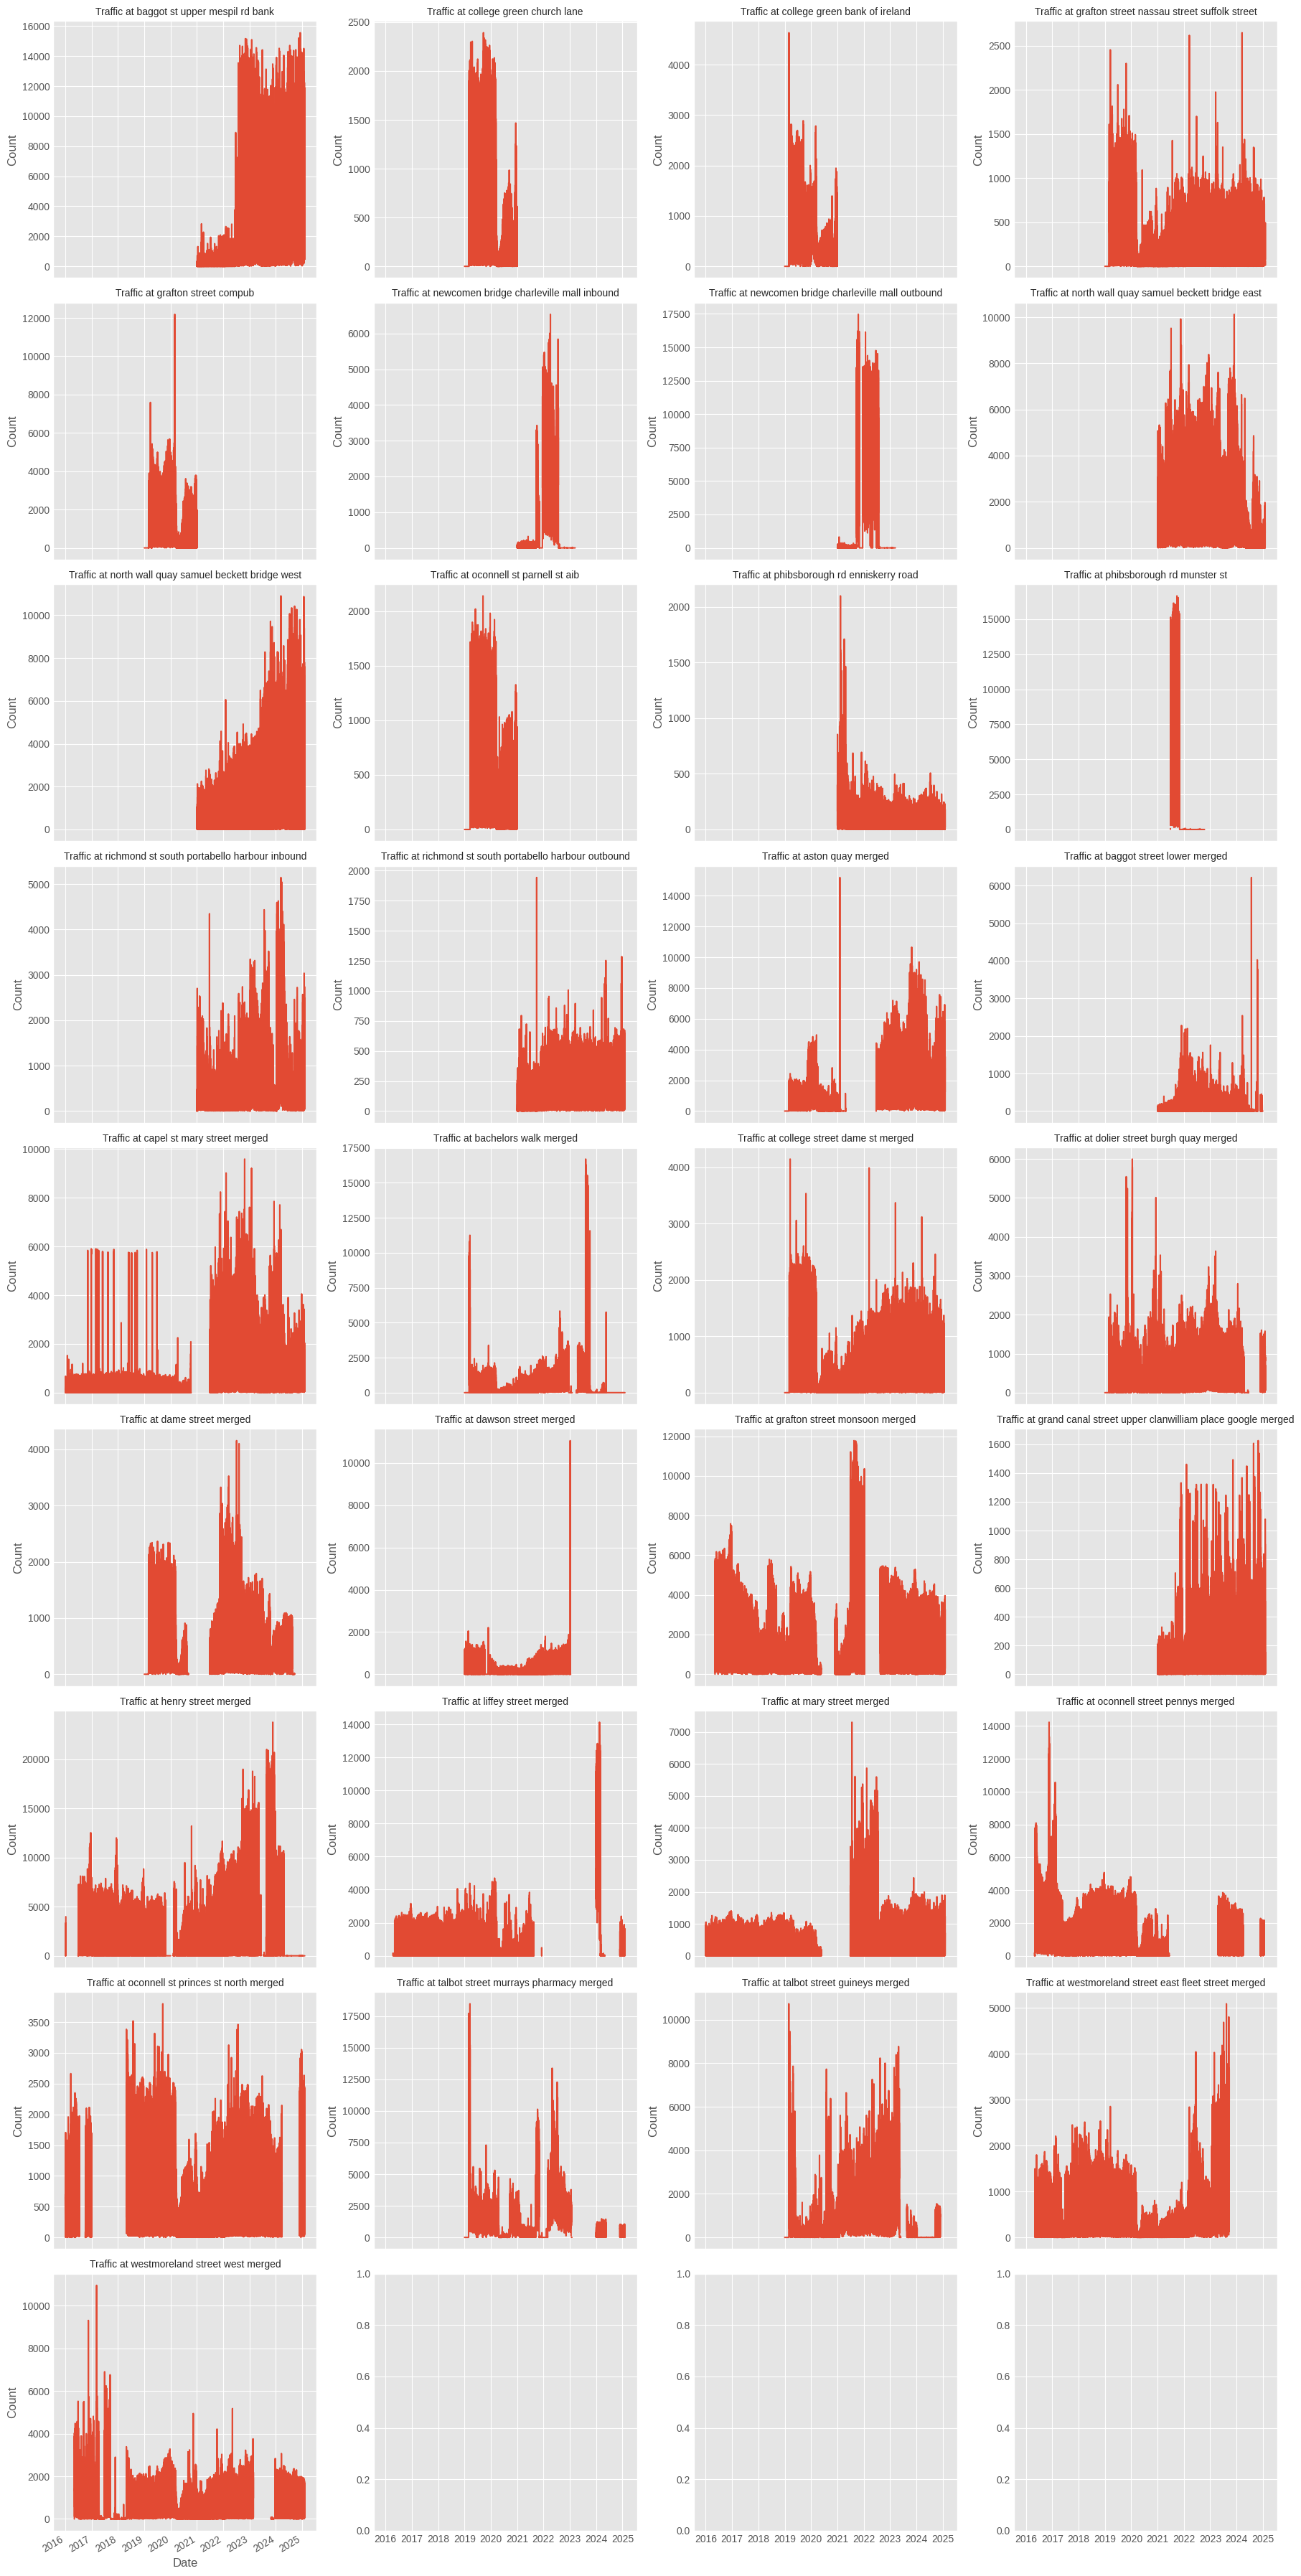

In [41]:
plot_time_series_grid(footfall)

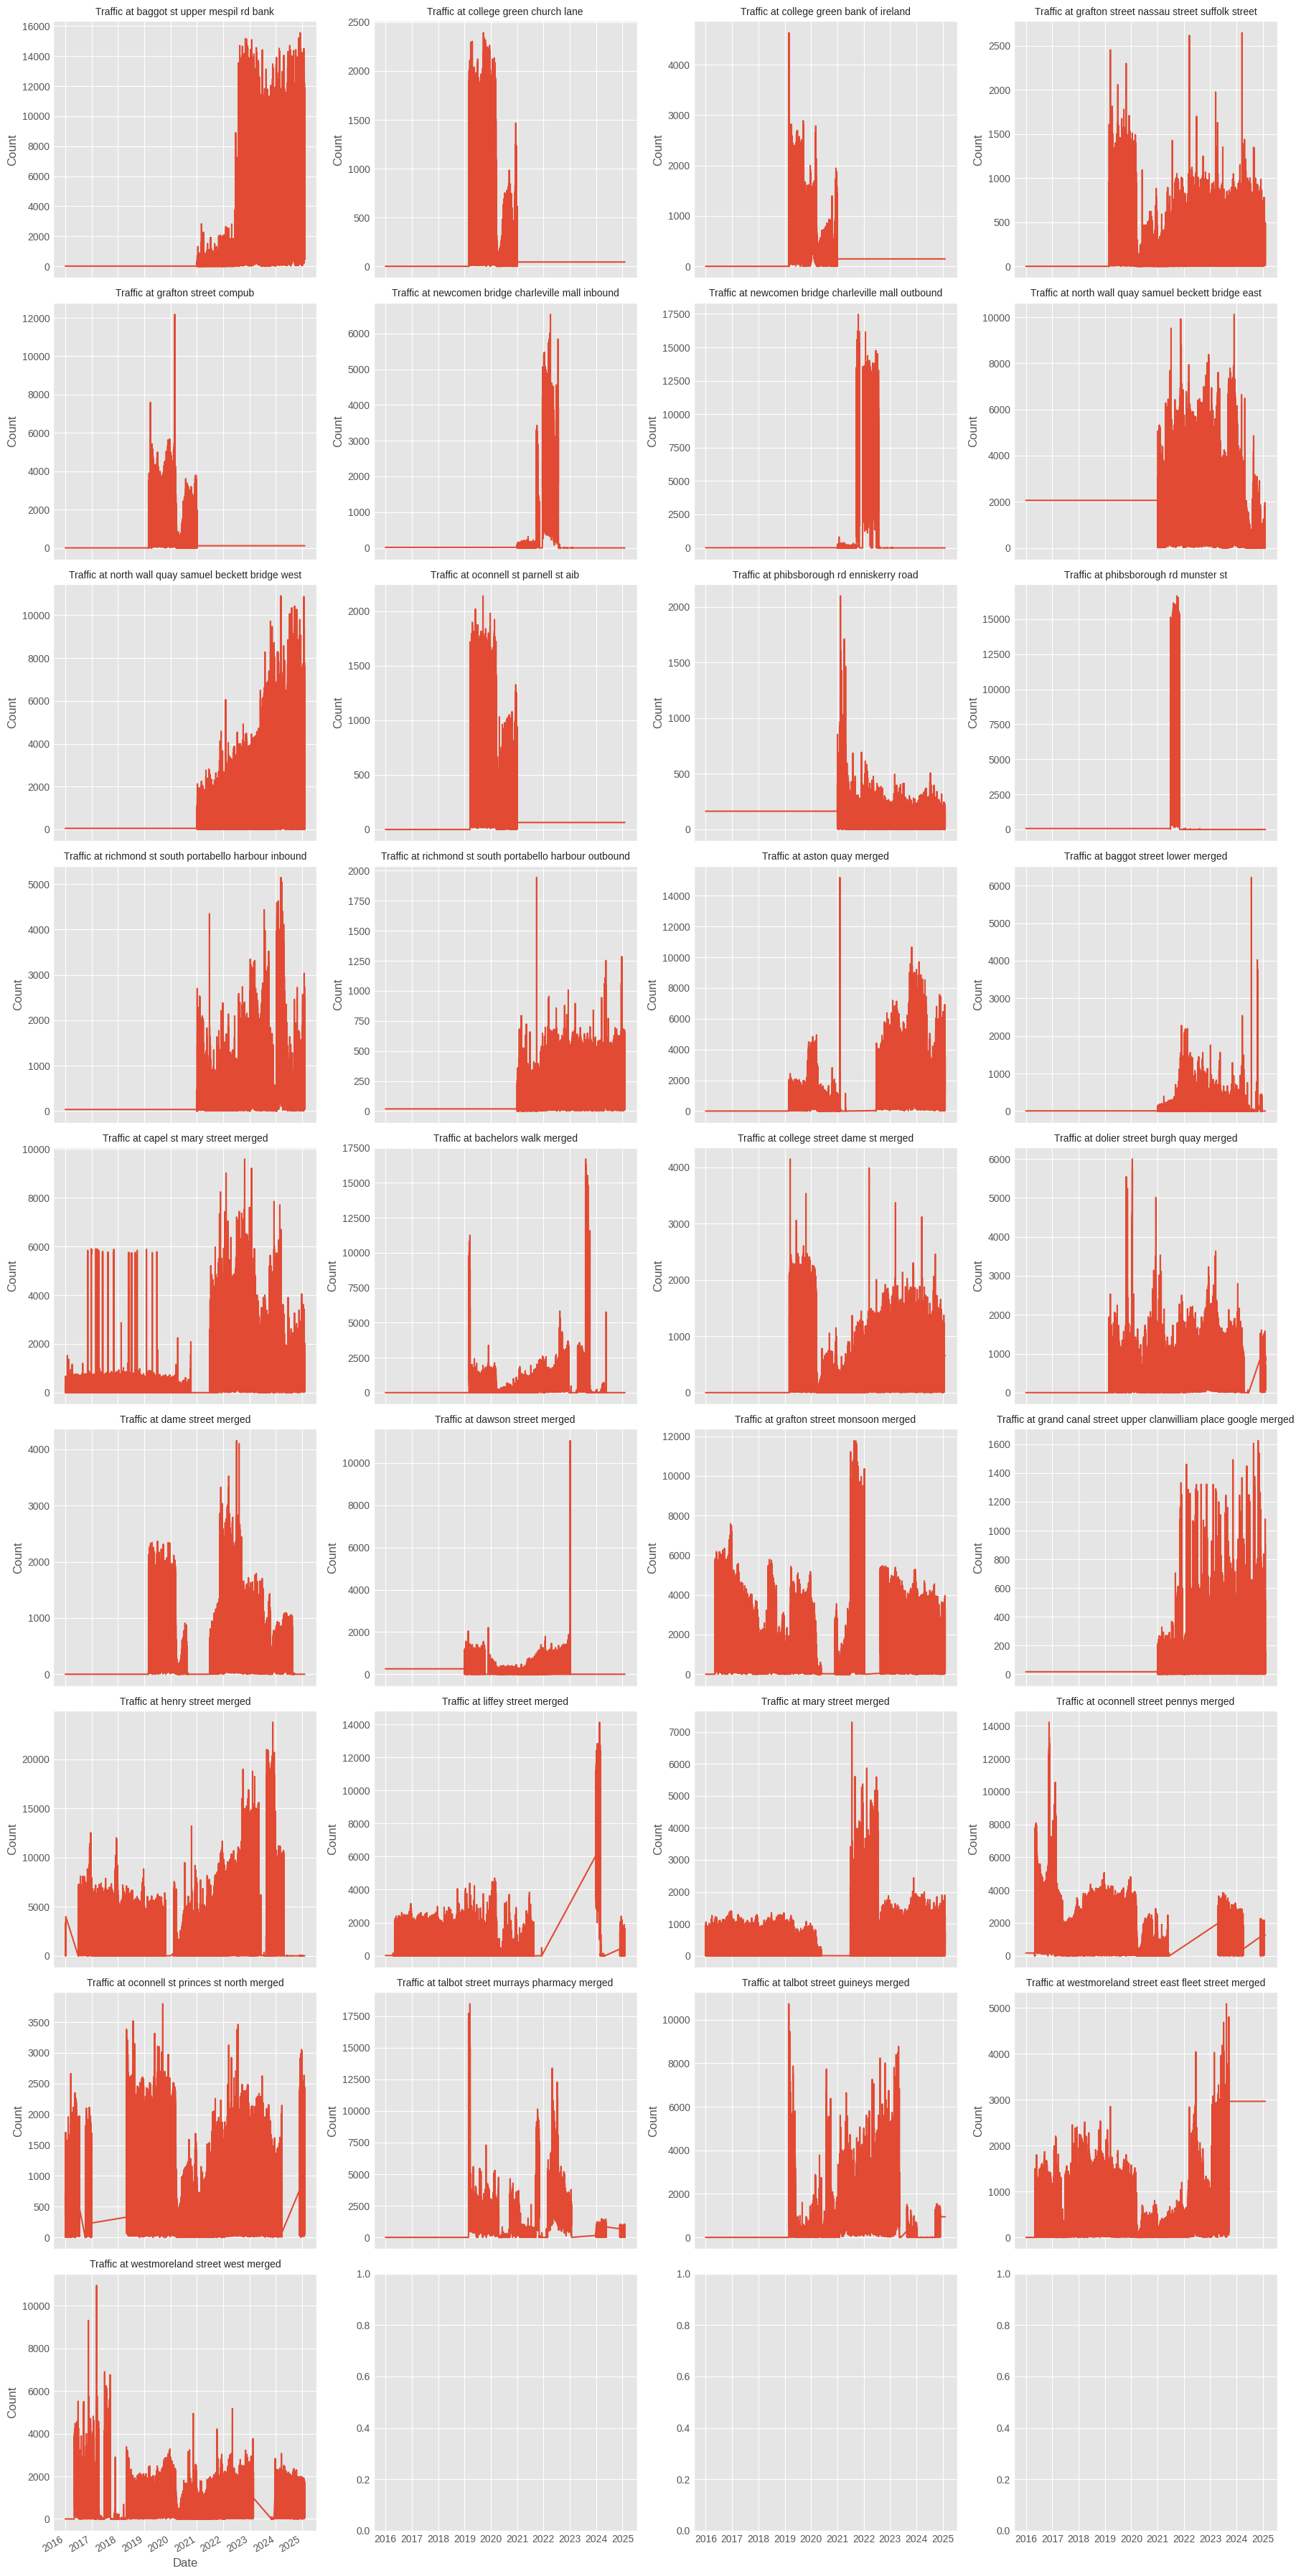

In [42]:
# Interpolation of numerical columns for missing values
def interpolation(data):
    data_interpolated = data.copy()
    numeric_cols = data.select_dtypes(include=["number"]).columns
    for col in numeric_cols:
        if data[col].isna().any():
            data_interpolated[col] = data_interpolated[col].interpolate(method="linear", limit_direction="both") # Interpolate linearly
            data_interpolated[col] = data_interpolated[col].fillna(0) # Fill remaining missing values with 0
    return data_interpolated

# Interpolate numeric columns missing values
footfall_int = interpolation(footfall)
plot_time_series_grid(footfall_int)

Interpolation seems not to be the most suitable option to fill in missing values, as it is not able to recognise footfall patterns precisely as needed for the study resulting in bias. Filling missing values with zeros will result in a more reliable option considering there is no record of pedestrian in the time and location specified.

In [43]:
# Order columns and fill missing values

def order_cols(data, datetime_col="date and time"):
    # Get all columns except the datetime column
    other_cols = [col for col in data.columns if col != datetime_col]
    # Sort other columns alphabetically
    other_cols_sorted = sorted(other_cols)
    # Create new column order with datetime_col first
    new_order = [datetime_col] + other_cols_sorted
    # Reorder dataframe columns
    data = data[new_order]
    # Fill NaNs with 0 inplace
    data.fillna(value=0, inplace=True)
    return data

footfall = order_cols(footfall)
print(footfall.shape)
footfall.head()

(79727, 38)


,date and time,aston quay merged,bachelors walk merged,baggot st upper mespil rd bank,baggot street lower merged,capel st mary street merged,college green bank of ireland,college green church lane,college street dame st merged,dame street merged,dawson street merged,dolier street burgh quay merged,grafton street compub,grafton street monsoon merged,grafton street nassau street suffolk street,grand canal street upper clanwilliam place google merged,henry street merged,hour,liffey street merged,mary street merged,month,newcomen bridge charleville mall inbound,newcomen bridge charleville mall outbound,north wall quay samuel beckett bridge east,north wall quay samuel beckett bridge west,oconnell st parnell st aib,oconnell st princes st north merged,oconnell street pennys merged,phibsborough rd enniskerry road,phibsborough rd munster st,richmond st south portabello harbour inbound,richmond st south portabello harbour outbound,talbot street guineys merged,talbot street murrays pharmacy merged,weekday,westmoreland street east fleet street merged,westmoreland street west merged,year
0,2016-01-01 00:00:00,0.0,0.0,0.0,0.0,120.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,67.0,1,0.0,0.0,0.0,0.0,0.0,656.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0,0.0,2016
1,2016-01-01 01:00:00,0.0,0.0,0.0,0.0,139.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,75.0,1,0.0,0.0,0.0,0.0,0.0,529.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0,0.0,2016
2,2016-01-01 02:00:00,0.0,0.0,0.0,0.0,125.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,0.0,69.0,1,0.0,0.0,0.0,0.0,0.0,676.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0,0.0,2016
3,2016-01-01 03:00:00,0.0,0.0,0.0,0.0,196.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,0.0,58.0,1,0.0,0.0,0.0,0.0,0.0,702.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0,0.0,2016
4,2016-01-01 04:00:00,0.0,0.0,0.0,0.0,130.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0,43.0,1,0.0,0.0,0.0,0.0,0.0,305.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0,0.0,2016


In [44]:
footfall.describe()

,date and time,aston quay merged,bachelors walk merged,baggot st upper mespil rd bank,baggot street lower merged,capel st mary street merged,college green bank of ireland,college green church lane,college street dame st merged,dame street merged,dawson street merged,dolier street burgh quay merged,grafton street compub,grafton street monsoon merged,grafton street nassau street suffolk street,grand canal street upper clanwilliam place google merged,henry street merged,hour,liffey street merged,mary street merged,month,newcomen bridge charleville mall inbound,newcomen bridge charleville mall outbound,north wall quay samuel beckett bridge east,north wall quay samuel beckett bridge west,oconnell st parnell st aib,oconnell st princes st north merged,oconnell street pennys merged,phibsborough rd enniskerry road,phibsborough rd munster st,richmond st south portabello harbour inbound,richmond st south portabello harbour outbound,talbot street guineys merged,talbot street murrays pharmacy merged,weekday,westmoreland street east fleet street merged,westmoreland street west merged,year
count,79727,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000,79727.000000
mean,2020-07-18 23:38:35.908036352,958.346081,418.380473,1358.515421,58.084764,627.292435,117.600763,111.925433,323.466467,318.048616,113.216928,435.191968,296.205664,1263.862368,170.169867,61.296336,1948.974864,11.500169,477.356391,367.339747,6.466329,173.569443,522.131837,838.242440,657.644060,105.973748,567.153072,891.509288,52.703287,319.785957,289.835275,97.091600,627.798299,727.101233,3.000865,417.172326,682.187916,2020.051187
min,2016-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2016.000000
25%,2018-04-10 11:30:00,0.000000,0.000000,0.000000,0.000000,64.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,85.000000,0.000000,0.000000,38.000000,6.000000,0.000000,17.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,17.000000,2018.000000
50%,2020-07-19 00:00:00,5.000000,0.000000,0.000000,0.000000,320.000000,0.000000,0.000000,69.000000,4.000000,0.000000,124.000000,0.000000,622.000000,36.000000,0.000000,514.000000,12.000000,50.000000,124.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,320.000000,228.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,3.000000,188.000000,453.000000,2020.000000
75%,2022-10-27 11:30:00,1352.000000,454.000000,833.500000,41.000000,720.000000,0.000000,0.000000,537.000000,542.000000,108.500000,808.000000,0.000000,1974.000000,267.000000,74.000000,3159.000000,17.500000,625.000000,569.000000,9.000000,0.000000,0.000000,1128.000000,679.000000,0.000000,1006.000000,1404.000000,91.000000,0.000000,410.000000,184.000000,874.500000,758.000000,5.000000,681.000000,1145.000000,2022.000000
max,2025-02-03 23:00:00,15190.000000,16703.000000,15564.000000,6217.000000,9591.000000,4632.000000,2392.000000,4147.000000,4155.000000,11062.000000,5995.000000,12188.000000,11778.000000,2649.000000,1626.000000,23785.000000,23.000000,14129.000000,7303.000000,12.000000,6536.000000,17468.000000,10124.000000,10906.000000,2141.000000,3798.000000,14235.000000,2098.000000,16657.000000,5148.000000,1944.000000,10729.000000,18483.000000,6.000000,5091.000000,

Percentiles indicate that 50% of the data remains as low count of pedestrian or zero, meanwhile from 75% to maximum percentile relies on values of hundreds to values above seventeen thousand, which means there could be too many zero values located or events that indicate very high peaks where pedestrians are concentrated at the sane time.

### **HANDLING MISSING VALUES**

In [45]:
# Percentage of 0 values per column
zero_percent = (footfall == 0).sum() / len(footfall) * 100
print("Percentage of 0 values per column:")
print(zero_percent.sort_values(ascending=False))

# Identify columns with over 50% zeros
columns_to_drop = [
    col for col in footfall.columns
    if zero_percent[col] > 50
]

# Drop columns with more than 50% of zeros
footfall.drop(columns=columns_to_drop, inplace=True)

print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop} from the dataset")

Percentage of 0 values per column:
phibsborough rd munster st                                  96.050272
newcomen bridge charleville mall inbound                    84.322751
newcomen bridge charleville mall outbound                   84.292649
oconnell st parnell st aib                                  80.335395
grafton street compub                                       80.161050
college green church lane                                   79.970399
college green bank of ireland                               79.833682
baggot street lower merged                                  63.288472
dawson street merged                                        58.538513
baggot st upper mespil rd bank                              55.450475
grand canal street upper clanwilliam place google merged    55.294944
phibsborough rd enniskerry road                             55.224704
north wall quay samuel beckett bridge east                  55.111819
richmond st south portabello harbour outbound          

In [46]:
def add_prefix_to_columns(data, prefix="FTF_", exclude_col="date and time"):
    data = data.copy()
    for col in ["date", "Date and time", "Date & time", "Date And Time"]: # variations
        if col in data.columns and col.lower() != "date and time":
            data.rename(columns={col: "date and time"}, inplace=True)
    normalized_exclude = "date and time"

    def clean_column_name(col):
        if col.lower() == normalized_exclude:
            return col
        col = re.sub(r"\bstreet\b", "st", col, flags=re.IGNORECASE)
        col = re.sub(r"\bsroad\b", "rd", col, flags=re.IGNORECASE)
        col = col.title()
        return f"{prefix}{col}"

    data.rename(columns={col: clean_column_name(col) for col in data.columns}, inplace=True)
    return data

In [47]:
# Dropping redundant columns
footfall.drop(columns=["hour", "weekday", "month", "year"], errors="ignore", inplace=True)
footfall = add_prefix_to_columns(footfall)
footfall["date and time"] = pd.to_datetime(footfall["date and time"])

# Filter data from 01-01-2019 for study purposes
footfall = footfall[footfall["date and time"] >= pd.to_datetime("2019-01-01")]
footfall.reset_index(drop=True, inplace=True)
footfall.head()

,date and time,FTF_Aston Quay Merged,FTF_Capel St Mary St Merged,FTF_College St Dame St Merged,FTF_Dame St Merged,FTF_Dolier St Burgh Quay Merged,FTF_Grafton St Monsoon Merged,FTF_Grafton St Nassau St Suffolk St,FTF_Henry St Merged,FTF_Liffey St Merged,FTF_Mary St Merged,FTF_Oconnell St Princes St North Merged,FTF_Oconnell St Pennys Merged,FTF_Talbot St Guineys Merged,FTF_Westmoreland St East Fleet St Merged,FTF_Westmoreland St West Merged
0,2019-01-01 00:00:00,0.0,238.0,0.0,0.0,0.0,140.0,0.0,597.0,881.0,163.0,1914.0,1504.0,0.0,1670.0,1988.0
1,2019-01-01 01:00:00,0.0,173.0,0.0,0.0,0.0,215.0,0.0,359.0,723.0,102.0,885.0,1187.0,0.0,767.0,1270.0
2,2019-01-01 02:00:00,0.0,121.0,0.0,0.0,0.0,210.0,0.0,317.0,1010.0,63.0,984.0,1233.0,0.0,642.0,1589.0
3,2019-01-01 03:00:00,0.0,174.0,0.0,0.0,0.0,204.0,0.0,313.0,772.0,59.0,935.0,1316.0,0.0,582.0,1534.0
4,2019-01-01 04:00:00,0.0,82.0,0.0,0.0,0.0,88.0,0.0,172.0,197.0,46.0,390.0,802.0,0.0,143.0,610.0


In [48]:
# Percentage of 0 values per column
zero_percent = (footfall == 0).sum() / len(footfall) * 100
print("Percentage of 0 values per column:")
print(zero_percent.sort_values(ascending=False))

# Identify columns with over 40% zeros
columns_to_drop = [
    col for col in footfall.columns
    if zero_percent[col] > 40 and col.startswith("FTF")
]

# Drop columns with more than 40% of zeros
footfall.drop(columns=columns_to_drop, inplace=True)

print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop} from the dataset")

Percentage of 0 values per column:
FTF_Liffey St Merged                        50.442693
FTF_Oconnell St Pennys Merged               44.374146
FTF_Aston Quay Merged                       25.133370
FTF_Dame St Merged                          24.852592
FTF_Westmoreland St East Fleet St Merged    22.973251
FTF_Henry St Merged                         22.582034
FTF_Talbot St Guineys Merged                22.172098
FTF_Grafton St Monsoon Merged               19.993261
FTF_Mary St Merged                          18.347903
FTF_Westmoreland St West Merged             15.233139
FTF_Dolier St Burgh Quay Merged             12.960710
FTF_Capel St Mary St Merged                 11.949909
FTF_Oconnell St Princes St North Merged     11.126294
FTF_Grafton St Nassau St Suffolk St          4.471857
FTF_College St Dame St Merged                3.768040
date and time                                0.000000
dtype: float64
Dropped 2 columns: ['FTF_Liffey St Merged', 'FTF_Oconnell St Pennys Merged'] from the 

### **CORREALTION BETWEEN VARIABLES**

In [49]:
# Time components
time_components = extract_time_components(footfall)

# Merging footfall and time components datatframes
footfall = pd.concat([footfall, time_components], axis=1)

Missing values: 0


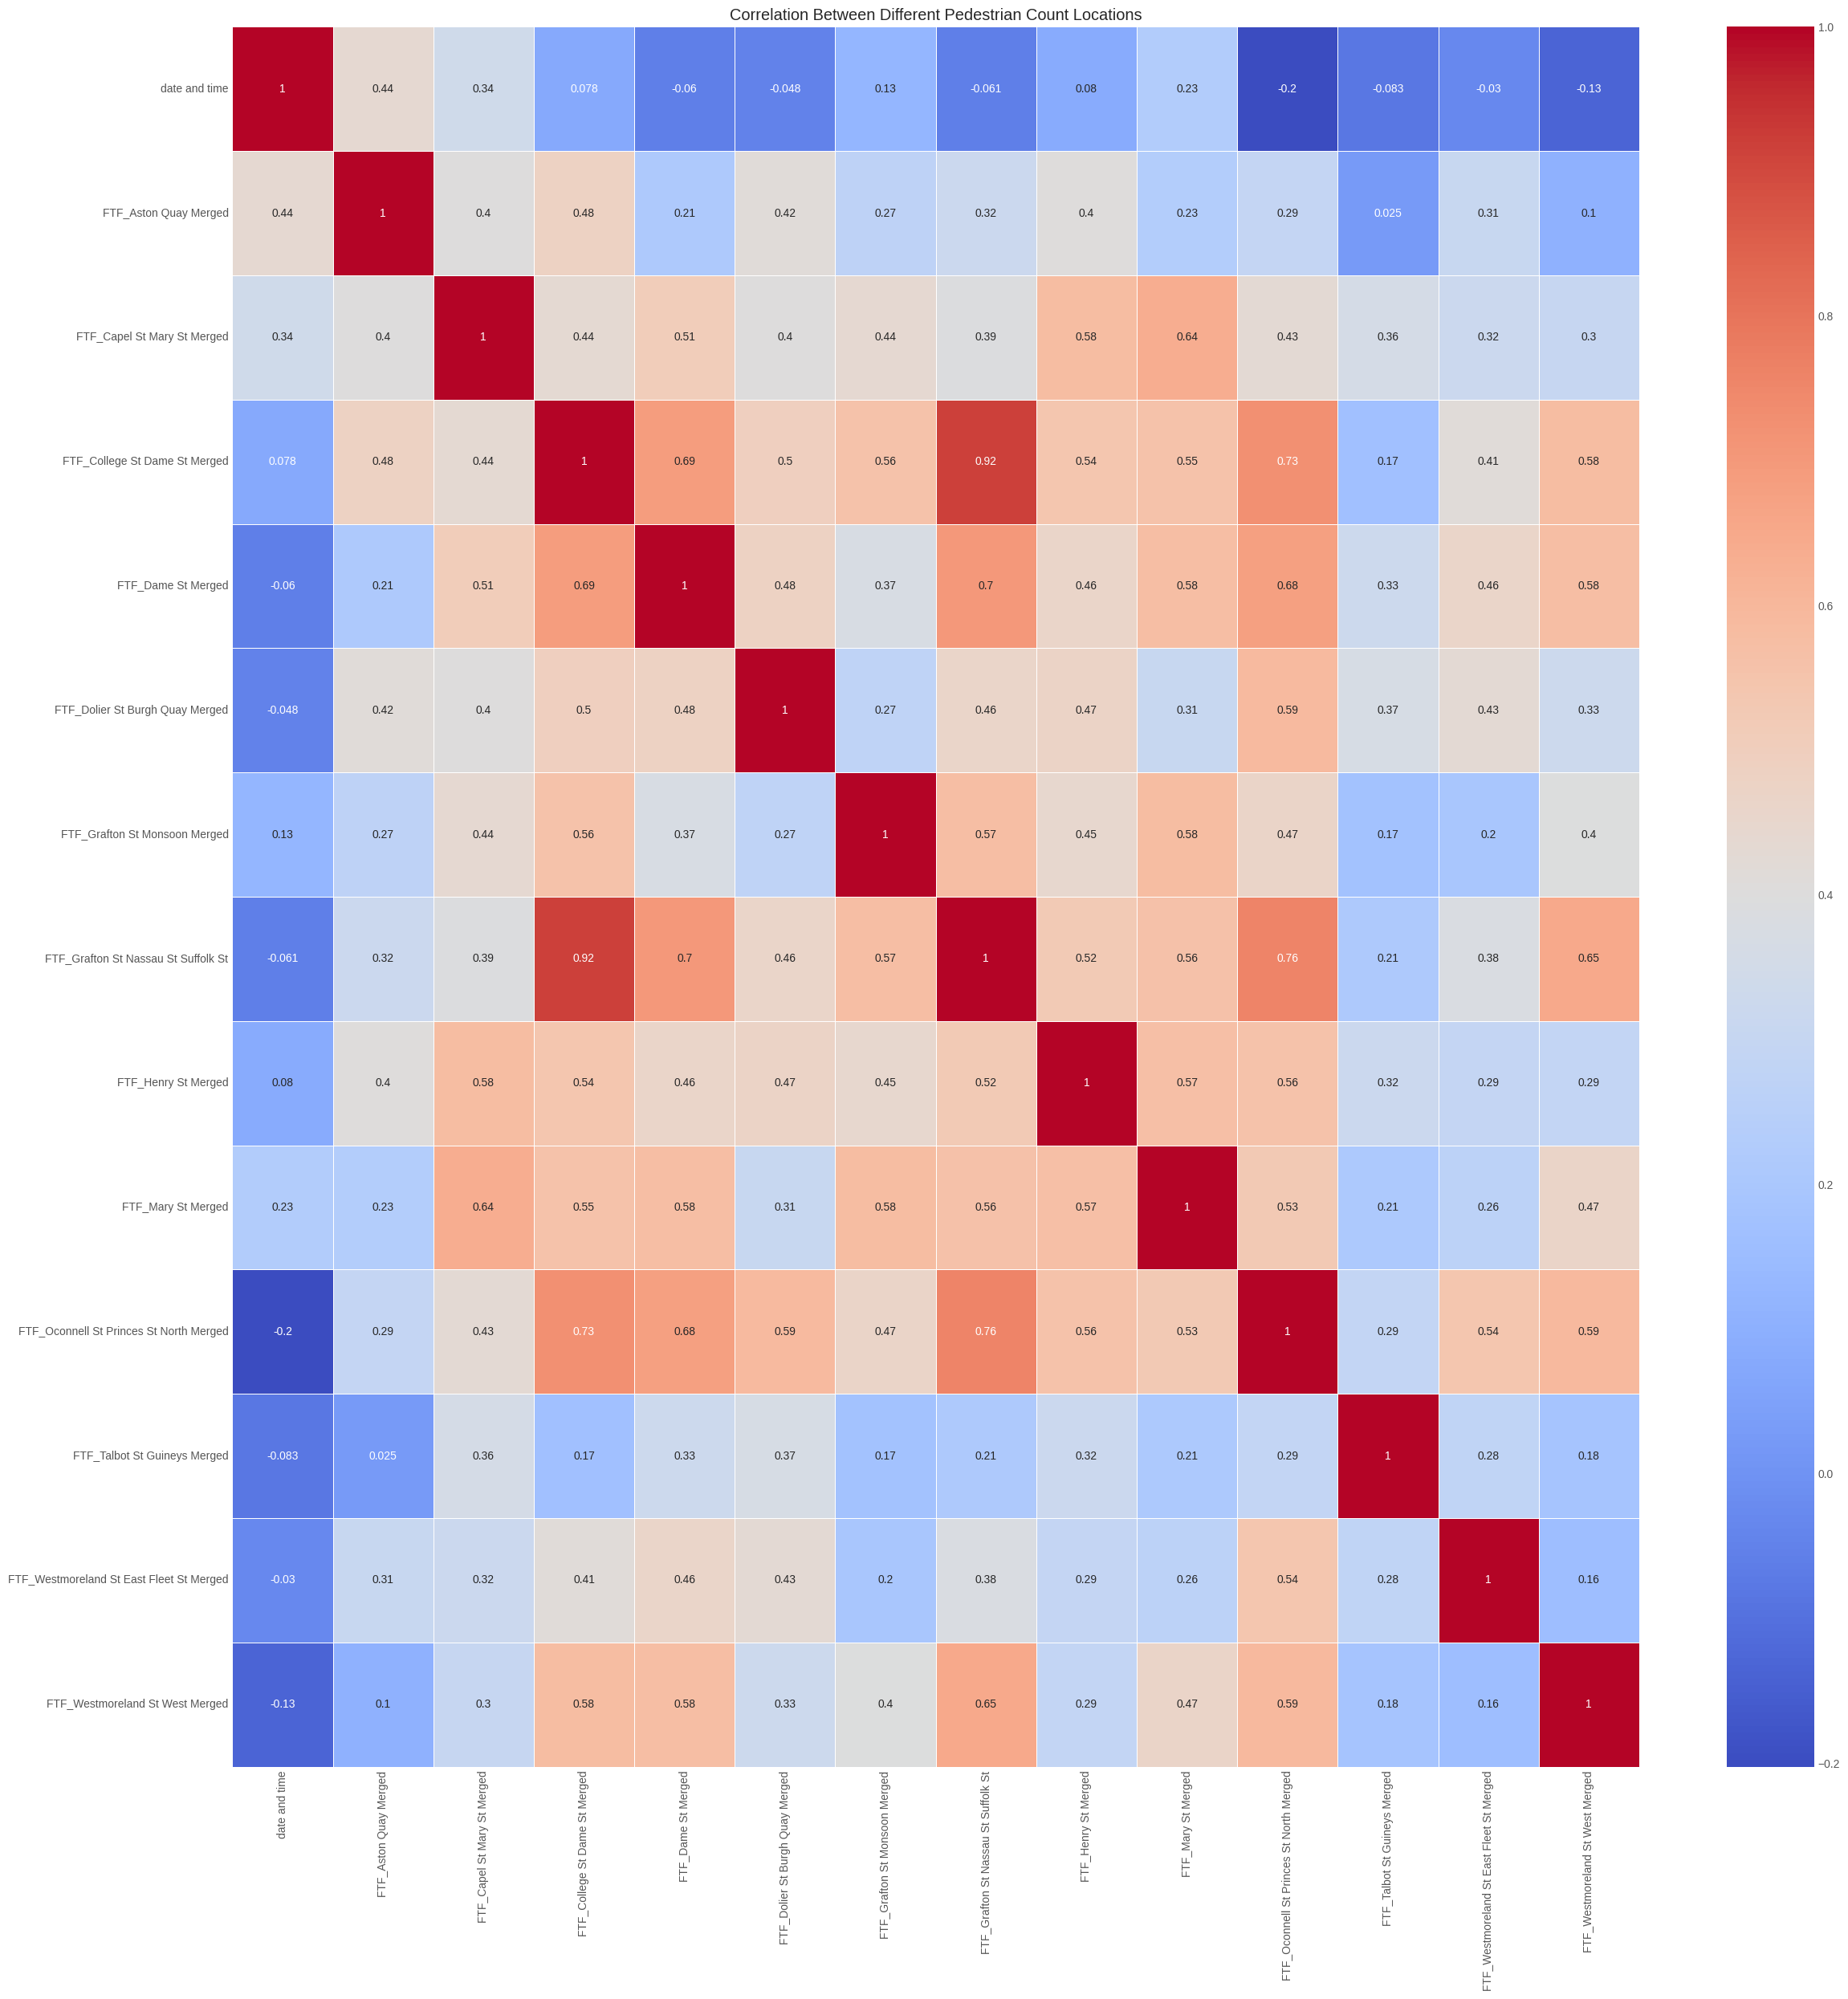

In [50]:
# Check for any remaining missing values
print(f"Missing values: {footfall.isnull().sum().sum()}")

# Exclude the specified columns
columns_to_exclude = ["year", "month", "weekday", "hour"]
footfall_filtered = footfall.drop(columns=columns_to_exclude)

# Calculate correlation matrix
correlation_filtered = footfall_filtered.corr()

# Plot heatmap
plt.figure(figsize=(25, 25))
sns.heatmap(correlation_filtered, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Different Pedestrian Count Locations")
plt.tight_layout()
plt.show()


Streets that have near locations are highly correlated, which indicates the number of pedestrian influence as the pedestrian flow within the city is sequential.

Also it highlights, that a most of the counter locations could be highly correlated to external factors rather than date and time.

### **BUSIEST TIME AND DAYS PER STREET**

In [51]:
columns_to_exclude = ["year", "month", "weekday", "hour"]

# Filter columns excluding "date and time" and all columns in columns_to_exclude
location_cols = [col for col in footfall.columns if col not in ["date and time"] + columns_to_exclude]

# Group by "hour" column from original DataFrame and sum only location columns
peak_hours = footfall[location_cols].groupby(footfall["hour"]).sum().idxmax()

print("Peak traffic hours by location:")
print(peak_hours)

print("\nPeak traffic hours count:")
print(peak_hours.value_counts())

# Group by "weekday" column from original DataFrame and sum only location columns
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
peak_days = footfall[location_cols].groupby(footfall["weekday"]).sum().idxmax()

# Display the results
print("\nPeak traffic days by location:")
for location, day in peak_days.items():
    print(f"{location}: {days[day]}")

print("\nPeak traffic days count:")
print(peak_days.value_counts())

Peak traffic hours by location:
FTF_Aston Quay Merged                       18
FTF_Capel St Mary St Merged                 13
FTF_College St Dame St Merged               17
FTF_Dame St Merged                          17
FTF_Dolier St Burgh Quay Merged             17
FTF_Grafton St Monsoon Merged               13
FTF_Grafton St Nassau St Suffolk St         13
FTF_Henry St Merged                         16
FTF_Mary St Merged                          13
FTF_Oconnell St Princes St North Merged     17
FTF_Talbot St Guineys Merged                18
FTF_Westmoreland St East Fleet St Merged    17
FTF_Westmoreland St West Merged             17
dtype: int32

Peak traffic hours count:
17    6
13    4
18    2
16    1
Name: count, dtype: int64

Peak traffic days by location:
FTF_Aston Quay Merged: Thursday
FTF_Capel St Mary St Merged: Saturday
FTF_College St Dame St Merged: Friday
FTF_Dame St Merged: Friday
FTF_Dolier St Burgh Quay Merged: Friday
FTF_Grafton St Monsoon Merged: Saturday
FTF_Grafton 

The busiest time for most of locations seems to be during the 17:00 followed by 13:00. And the busiest day seems to be Saturday followed by Friday. Which could indicate that pedestrian patterns could highly related to leisure-related behaviours during the weekend, and timetables and businesses around the locations of pedestrian counters.

In [52]:
columns_to_exclude = ["year", "month", "weekday", "hour"]
location_cols = [col for col in footfall.columns if col not in ["date and time"] + columns_to_exclude]

# Group by day and hour and sum location columns
peak_day_hour = footfall.groupby(["weekday", "hour"])[location_cols].sum()
peak_day_hour_total = peak_day_hour.sum(axis=1)
peak_combination = peak_day_hour_total.idxmax()

# Filter the rows matching the peak day and hour
busiest_rows = footfall[(footfall["weekday"] == peak_combination[0]) &
                       (footfall["hour"] == peak_combination[1])]

# Find the specific row with the highest traffic sum for location columns
busiest_row_index = busiest_rows[location_cols].sum(axis=1).idxmax()
busiest_row = footfall.loc[busiest_row_index]

print("\nAs DataFrame:")
footfall.loc[[busiest_row_index]]



As DataFrame:


,date and time,FTF_Aston Quay Merged,FTF_Capel St Mary St Merged,FTF_College St Dame St Merged,FTF_Dame St Merged,FTF_Dolier St Burgh Quay Merged,FTF_Grafton St Monsoon Merged,FTF_Grafton St Nassau St Suffolk St,FTF_Henry St Merged,FTF_Mary St Merged,FTF_Oconnell St Princes St North Merged,FTF_Talbot St Guineys Merged,FTF_Westmoreland St East Fleet St Merged,FTF_Westmoreland St West Merged,hour,weekday,month,year
37910,2023-04-29 15:00:00,4370.0,2261.0,1282.0,1002.0,951.0,4137.0,814.0,15414.0,1433.0,1775.0,8770.0,1595.0,0.0,15,5,4,2023


### **MAIN LOCATIONS MONTHLY TRENDS**

Using style: seaborn-v0_8-whitegrid


/tmp/ipython-input-3259352421.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = footfall.set_index("date and time")[location].resample("M").sum()


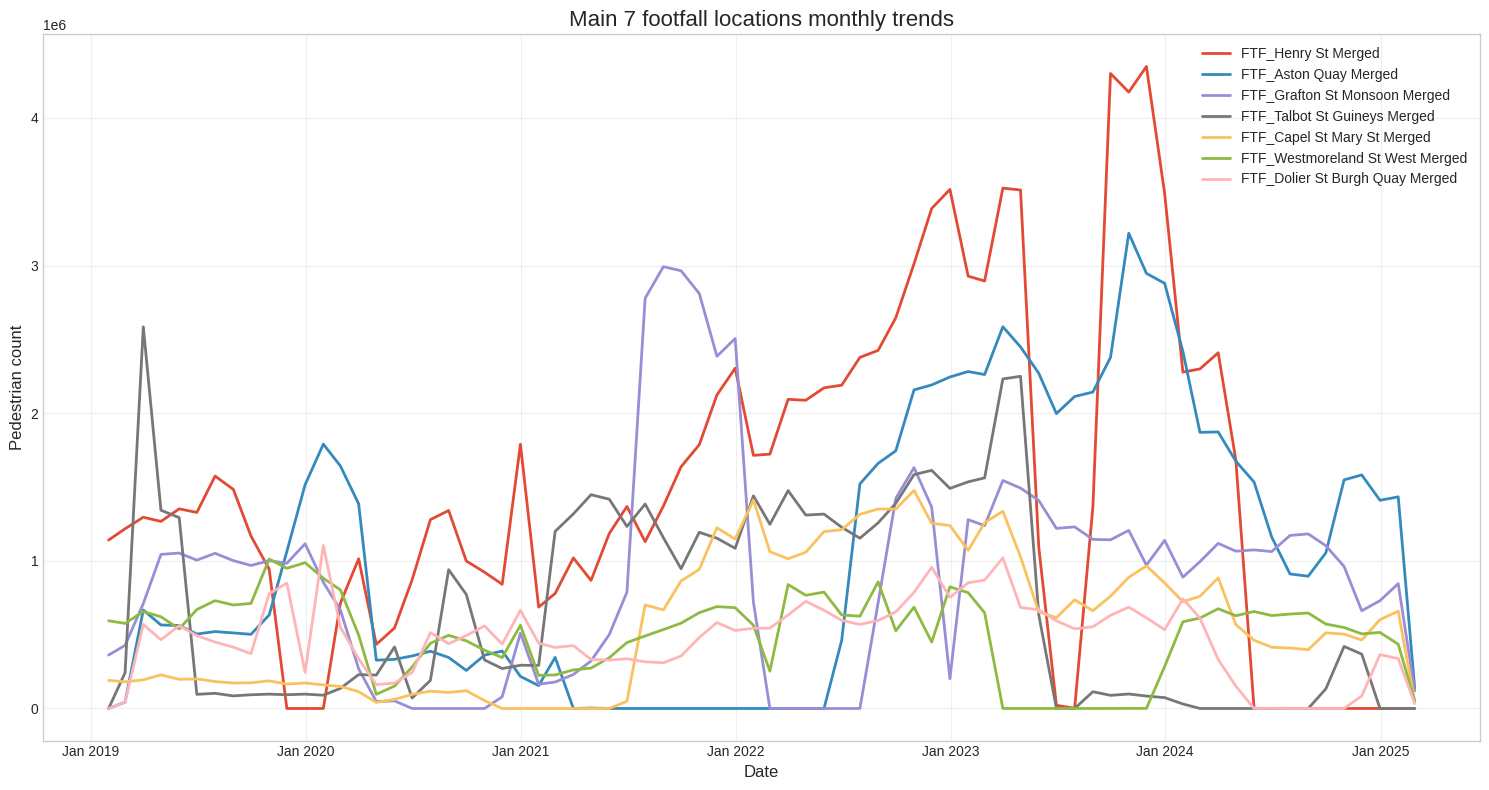

In [53]:
try:
    plt.style.use("seaborn-v0_8-whitegrid")
    print("Using style: seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
        print("Using style: seaborn-whitegrid")
    except OSError:
        # If seaborn styles are not found
        print("Seaborn styles not found. Falling back to 'ggplot'.")
        plt.style.use("ggplot")

# Top 7 most frequent location
top_locations = footfall[location_cols].sum().sort_values(ascending=False).head(7).index

# Plot
fig, ax = plt.subplots(figsize=(15, 8))
for location in top_locations:
    monthly_data = footfall.set_index("date and time")[location].resample("M").sum()
    ax.plot(monthly_data.index, monthly_data, linewidth=2, label=location)

ax.set_title("Main 7 footfall locations monthly trends", fontsize=16)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Pedestrian count", fontsize=12)
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.show()

Overal, all most frequent locations before 2020, held a moderate behaviour with no increasing but average trend. After 2020, all of them suggest the number of pedestrian increased drastically for most of them.

The most frequent locations in the datasets are leaded by Henry Street, located near the An Post General Post Office,  Jervis and ILAC Shopping Centres, it has a high number of pedestrian commuting in the area.

The sencond most frequent locations is Aston Quay, this area is located next to the Liffey River an area that can be used commonly for commuting, which could influence the number of pedestrians counted.

### **HOURLY PATTERNS BY DAY**

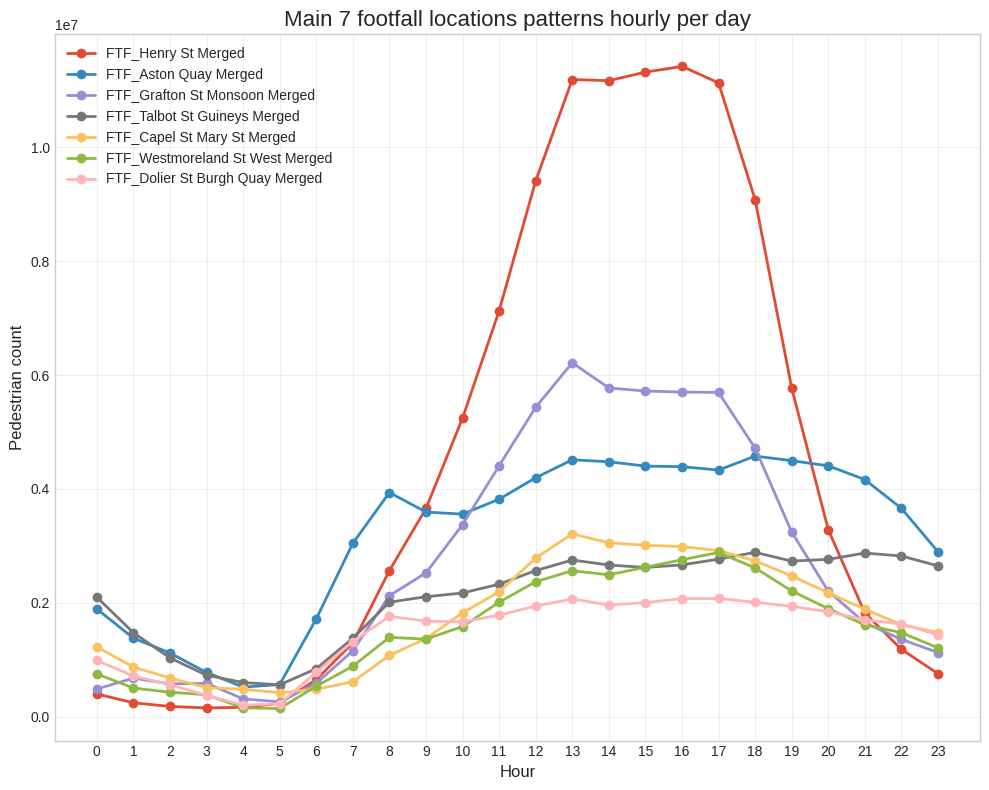

In [54]:
plt.figure(figsize=(10, 8))

# Data per hour during the day
hourly_pattern = footfall.groupby("hour")[location_cols].sum()

# Main locations
for location in top_locations:
    plt.plot(hourly_pattern.index, hourly_pattern[location], marker="o", linewidth=2, label=location)

plt.title("Main 7 footfall locations patterns hourly per day", fontsize=16)
plt.xlabel("Hour", fontsize=12)
plt.ylabel("Pedestrian count", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In an hourly pattern, Henry St remains as leader, with a consistent high number of pedestrians between 13:00 and 17:00. The same situation occurs in Grafton Steet, with a lower number of pedestrian but same peak hours.

### **DAILY PATTERNS BY DAY OF THE WEEK**

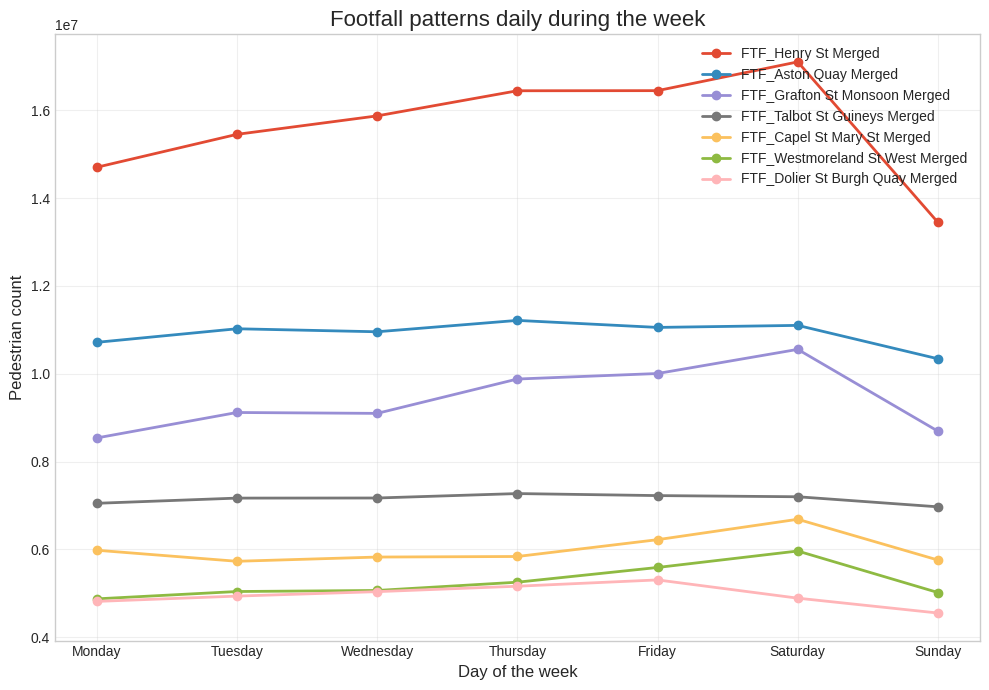

In [55]:
plt.figure(figsize=(10, 7))

# Days of the week
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Data per weekday
daily_pattern = footfall.groupby("weekday")[location_cols].sum()

# Main locations
for location in top_locations:
    plt.plot(daily_pattern.index, daily_pattern[location], marker="o", linewidth=2, label=location)
plt.title("Footfall patterns daily during the week", fontsize=16)
plt.xlabel("Day of the week", fontsize=12)
plt.ylabel("Pedestrian count", fontsize=12)
plt.xticks(range(7), days)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Considering daily patterns during the week,  Henry Street has a prominent number of pedestrians from Monday to Saturday and surprisingly, Sunday represents its lowest count.

Overall, in most frequent locations, Sunday represents the lowest number of pedestrians.

In [56]:
footfall.shape

(53423, 18)

In [57]:
footfall.head()

,date and time,FTF_Aston Quay Merged,FTF_Capel St Mary St Merged,FTF_College St Dame St Merged,FTF_Dame St Merged,FTF_Dolier St Burgh Quay Merged,FTF_Grafton St Monsoon Merged,FTF_Grafton St Nassau St Suffolk St,FTF_Henry St Merged,FTF_Mary St Merged,FTF_Oconnell St Princes St North Merged,FTF_Talbot St Guineys Merged,FTF_Westmoreland St East Fleet St Merged,FTF_Westmoreland St West Merged,hour,weekday,month,year
0,2019-01-01 00:00:00,0.0,238.0,0.0,0.0,0.0,140.0,0.0,597.0,163.0,1914.0,0.0,1670.0,1988.0,0,1,1,2019
1,2019-01-01 01:00:00,0.0,173.0,0.0,0.0,0.0,215.0,0.0,359.0,102.0,885.0,0.0,767.0,1270.0,1,1,1,2019
2,2019-01-01 02:00:00,0.0,121.0,0.0,0.0,0.0,210.0,0.0,317.0,63.0,984.0,0.0,642.0,1589.0,2,1,1,2019
3,2019-01-01 03:00:00,0.0,174.0,0.0,0.0,0.0,204.0,0.0,313.0,59.0,935.0,0.0,582.0,1534.0,3,1,1,2019
4,2019-01-01 04:00:00,0.0,82.0,0.0,0.0,0.0,88.0,0.0,172.0,46.0,390.0,0.0,143.0,610.0,4,1,1,2019


## **SAVE TO AZURE BLOB STORAGE**

In [58]:
def save_blob(data, filename):
    try:
        blob_name = f"{CONTAINER_NAME}/{filename}"
        csv_data = data.to_csv(index=False)
        with fs.open(blob_name, "w") as f:
            f.write(csv_data)
        print(f"Saved to {blob_name}")
    except Exception as e:
        print(f"Error saving data to blob storage: {str(e)}")
        return False

In [59]:
CONTAINER_NAME = "preprocessed"

save_blob(footfall, "footfall.csv")

Saved to preprocessed/footfall.csv


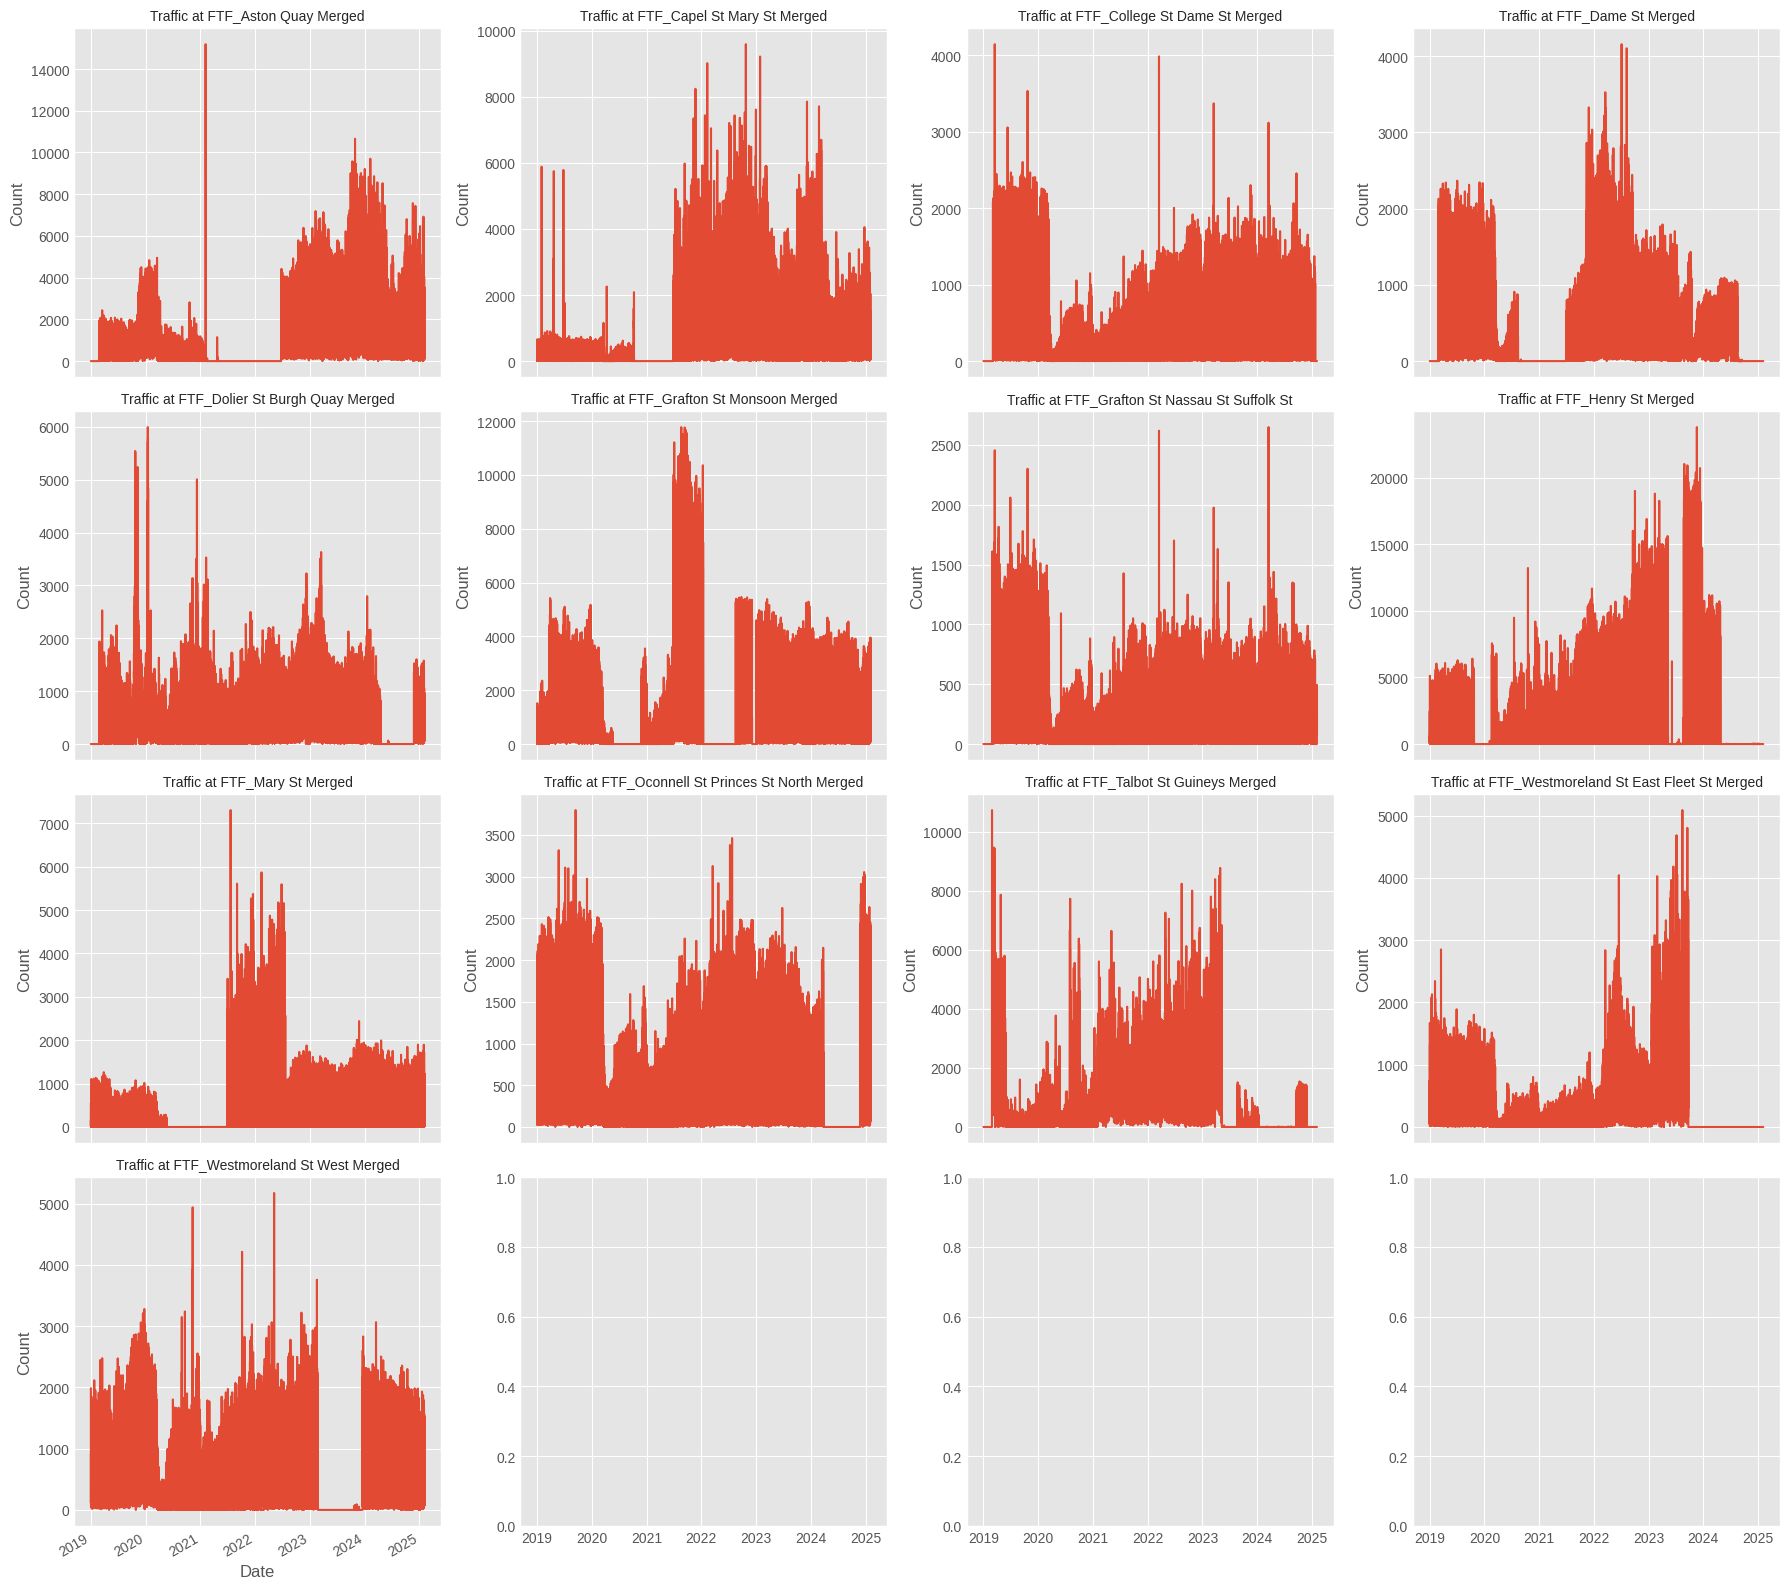

In [60]:
plot_time_series_grid(footfall)